## Decorrelation time

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from plm_hamming_dist import hamming_dist, energy_corr_array
from plm_seq_utils import read_tensor_from_txt, set_seed, letters_to_nums, modify_seq, nums_to_letters

## Comparing decorrelation time

In [21]:
cwd = '/Users/marzioformica/Desktop/EPFL/Master/MA2/Labo/my_project/PLM-gen-DCA/Attention-DCA-main'
#cwd='C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main'
save_dir_plm = 'generated_sequences'
filename_plm = 'generated_sequences_randinit_40000'
output_file = cwd + f'/CODE/AttentionDCA_python/src/PLM/{save_dir_plm}/{filename_plm}.npy'
plm_gen_seqs = np.load(output_file)

save_dir_mc = 'mc_generated_sequences'
filename_mc = 'mc_generated_sequences_randinit_100000'
output_file = cwd + f'/CODE/AttentionDCA_python/src/PLM/{save_dir_mc}/{filename_mc}.npy'
mc_gen_seqs = np.load(output_file)


PLM final correlation: -0.00993528077084529
MC final correlation: 0.016467032598147708


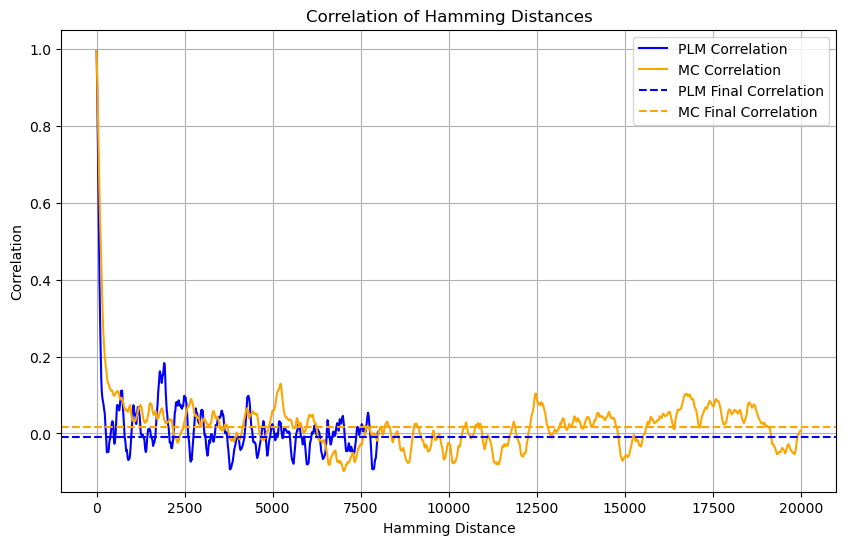

In [30]:
plm_init_seq = plm_gen_seqs[0]
mc_init_seq = mc_gen_seqs[0]
plm_hamming_distances = []
mc_hamming_distances = []
for seq in plm_gen_seqs:
    distance = hamming_dist(plm_init_seq, seq)
    plm_hamming_distances.append(distance)
plm_hamming_distances = np.array(plm_hamming_distances)
plm_correl = energy_corr_array(plm_hamming_distances, int(len(plm_hamming_distances)/5))
plm_final_correl = np.mean(plm_correl[-5000:])

for seq in mc_gen_seqs:
    distance = hamming_dist(mc_init_seq, seq)
    mc_hamming_distances.append(distance)
mc_hamming_distances = np.array(mc_hamming_distances)
mc_correl = energy_corr_array(mc_hamming_distances, int(len(mc_hamming_distances)/5))
mc_final_correl = np.mean(mc_correl[-10000:])

print(f"PLM final correlation: {plm_final_correl}")
print(f"MC final correlation: {mc_final_correl}")
# Plotting the correlation
plt.figure(figsize=(10, 6))
plt.plot(plm_correl, label='PLM Correlation', color='blue')
plt.plot(mc_correl, label='MC Correlation', color='orange')
plt.axhline(y=plm_final_correl, color='blue', linestyle='--', label='PLM Final Correlation')                
plt.axhline(y=mc_final_correl, color='orange', linestyle='--', label='MC Final Correlation')
plt.title('Correlation of Hamming Distances')
plt.xlabel('Hamming Distance')
plt.ylabel('Correlation')
plt.legend()
plt.grid()


In [31]:
# Estimate decorrelation time as index of the first crossing to final correlation average
plm_decorrelation_time = np.argmax(plm_correl < plm_final_correl)*5
mc_decorrelation_time = np.argmax(mc_correl < mc_final_correl)*5
print(f"PLM decorrelation time: {plm_decorrelation_time}")
print(f"MC decorrelation time: {mc_decorrelation_time}")

PLM decorrelation time: 1355
MC decorrelation time: 10795


In [32]:
# Select sequences with interval of decorrelation time
plm_selected_seqs = []
for i in range(0, len(plm_gen_seqs), plm_decorrelation_time):
    plm_selected_seqs.append(plm_gen_seqs[i])
plm_selected_seqs = np.array(plm_selected_seqs)
mc_selected_seqs = []
for i in range(0, len(mc_gen_seqs), mc_decorrelation_time):
    mc_selected_seqs.append(mc_gen_seqs[i])
mc_selected_seqs = np.array(mc_selected_seqs)
print(f"PLM selected sequences shape: {plm_selected_seqs.shape}")
print(f"MC selected sequences shape: {mc_selected_seqs.shape}")
# print first 10 sequences
print("PLM selected sequences:")
for i in range(10):
    print(nums_to_letters(plm_selected_seqs[i]))
print("MC selected sequences:")
for i in range(10):
    print(nums_to_letters(mc_selected_seqs[i]))


PLM selected sequences shape: (30, 63)
MC selected sequences shape: (10, 63)
PLM selected sequences:
PSAEEILYWFHPCHIRVGQKL-YTYGSSAWEVYYYRIACLAM-ENWDAAFGHK-VSFNMCCIL
LM-AVHGAHHFLERSVADVAHIR-SAFYRVMEAASASAVDVQTR-IKATNFMSMDERPGNVLP
KNGINYVIMQAIDVSSNKKISQSKFYELHLARNF-EG-NVRETSHVIHR-NDECKPISYADFT
DMYKLLQVGEK-DSRKIKKSYRILAITAHPDRNPDNSKSIDIFRKPVEAYSILVDPSRKRRYD
NPYAVLGVARDASDNEIENAYKKAAMAAHPDRY---DGDKERFRAATAAYELLRDERRRKVYD
DYYKLLGLDPDASDHDIAKAYRELQKQLHPDTV-HQEAAEQKFKQINEAYEVLKNPGQRSAYD
-PYSVLGVLPSADQSEIKAAFRKLAKQYHPDQNPDNPKAEEKFVDASSAYETLSDPRQRADYD
TYYQLLGVKLDTSEEEIKRAYRKLAKANHPDKNPDSENATQNFQTLVEAYRVLIDPKLRQKYD
DFYDVLNLPRDADQQQLTSAYRRLVRQTHPDSNPESPEASEKFVVVQEAYDILRDPELRAAF-
NYYVTLGVARTASQREIRAAYLRLAKEGHPDKLHGDEETEKHFKQVNAA-EVLGNSQEKAKYD
MC selected sequences:
PSAEEILYWFHPCHIRVGQKL-YTYGSSAWEVYYYRIACLAM-ENWDAAFGHK-VSFEMCCIL
HVAALVIKVEEIDMKCECIKQGPVARAYMRSLALDGAENMNLRVKLGEVCHVFSYQVHDPQPA
THFELFNVAESYDHVTLKAYYRQLSKRCHPDHIAVERMALELVATLNRAYKSLSFPTARARY-
DYYKILEIPKIATSEEIHQAYKKLSRAHHPDKYPDKDKEKDTFA

In [29]:
plm_init_seq = plm_gen_seqs[0]
mc_init_seq = mc_gen_seqs[0]
plm_hamming_distances = []
mc_hamming_distances = []
plm_correls = []
# divide sequences into groups of length plm_decorrelation_time
plm_gen_seqs_split = np.array_split(plm_gen_seqs, len(plm_gen_seqs)/(plm_decorrelation_time/5))
# loop over groups
for group in tqdm(plm_gen_seqs_split):
    # loop over sequences in group, taking the first sequence of each group as the reference
    group_init_seq = group[0]
    for seq in group:
        distance = hamming_dist(group_init_seq, seq)
        plm_hamming_distances.append(distance)
        plm_hamming_distances_array = np.array(plm_hamming_distances)
    plm_correl = energy_corr_array(plm_hamming_distances_array, int(len(plm_hamming_distances)/5))
    plm_correls.append(plm_correl)
plm_correls = np.array(plm_correls)
#plm_hamming_distances = np.array(plm_hamming_distances)
#plm_correl = energy_corr_array(plm_hamming_distances, int(len(plm_hamming_distances)/5))
#plot
plt.figure(figsize=(10, 6))
plt.plot(plm_correls, label='PLM Correlation', color='blue')
plt.axhline(y=plm_final_correl, color='blue', linestyle='--', label='PLM Final Correlation')
plt.title('Correlation of Hamming Distances')
plt.xlabel('Hamming Distance')
plt.ylabel('Correlation')
plt.legend()
plt.grid()

#plm_final_correl = np.mean(plm_correl[-10000:])
















































































































































100%|██████████| 156/156 [02:22<00:00,  1.09it/s]


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (156,) + inhomogeneous part.



100%|██████████| 1/1 [00:00<00:00,  1.48it/s]


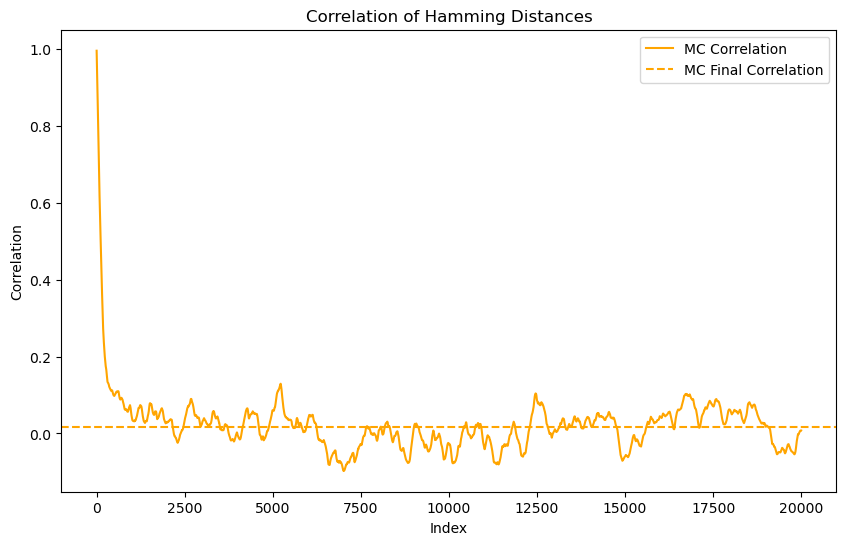

In [27]:
# Now do the same for mc_gen_seqs
# divide sequences into groups of length mc_decorrelation_time
mc_gen_seqs_split = np.array_split(mc_gen_seqs, len(mc_gen_seqs)/(mc_decorrelation_time*5))
# loop over groups
for group in tqdm(mc_gen_seqs_split):
    # loop over sequences in group, taking the first sequence of each group as the reference
    group_init_seq = group[0]
    for seq in group:
        distance = hamming_dist(group_init_seq, seq)
        mc_hamming_distances.append(distance)
mc_hamming_distances = np.array(mc_hamming_distances)
mc_correl = energy_corr_array(mc_hamming_distances, int(len(mc_hamming_distances)/5))
#plot
plt.figure(figsize=(10, 6))     
plt.plot(mc_correl, label='MC Correlation', color='orange')
plt.axhline(y=mc_final_correl, color='orange', linestyle='--', label='MC Final Correlation')
plt.title('Correlation of Hamming Distances')
plt.xlabel('Index')
plt.ylabel('Correlation')
plt.legend()

In [11]:
decorrelated_indices = [0]  # start from the first sequence
threshold = plm_final_correl
N = len(plm_gen_seqs)
# track with tqdm progress bar
# Create the progress bar
progress_bar = tqdm(total=N - 1)  # Total iterations are N - 1

current_idx = 0
while current_idx < N - 1:
    ref_seq = plm_gen_seqs[current_idx]
    found = False

    for next_idx in range(current_idx + 1, N):
        next_seq = plm_gen_seqs[next_idx]
        hamming_array = [hamming_dist(ref_seq, s) for s in plm_gen_seqs[current_idx+1:next_idx+1]]
        hamming_array = np.array(hamming_array)

        if len(hamming_array) < 10:
            continue  # skip too-short segments

        corr = energy_corr_array(hamming_array, min(len(hamming_array), len(hamming_array) // 5))
        mean_corr = np.mean(corr[-100:])  # average over tail

        if mean_corr < threshold:
            decorrelated_indices.append(next_idx)
            current_idx = next_idx
            found = True
            break
    print("next")
    progress_bar.update(1)  # Update the progress bar for each iteration    
    if not found:
        break  # no more decorrelated sequences found

# Result: list of indices corresponding to decorrelated sequences
decorrelated_sequences = [plm_gen_seqs[i] for i in decorrelated_indices]

  0%|          | 1/39999 [01:05<728:45:00, 65.59s/it]


next


next


next


KeyboardInterrupt: 

### PLM sequences with varying beta

In [ ]:

#----------- Load sequences with different betas -------------
cwd = '/Users/marzioformica/Desktop/EPFL/Master/MA2/Labo/my_project/PLM-gen-DCA/Attention-DCA-main'
#cwd='C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main'
save_dir = 'generated_sequences'

betas = [0.01, 0.1, 0.5, 1, 2, 4, 8]
correlations_means = []
correlations_array = []  # Will become a 2D array: len(betas) x len(correlation steps)

for b in betas:
    filename = f'gen_seqs_w_init_seq_Ns30000_r0.1_b{b}'
    output_file = cwd + f'/CODE/AttentionDCA_python/src/PLM/{save_dir}/{filename}.npy'
    gen_sequences = np.load(output_file)

    initial_sequence = gen_sequences[0]
    hamming_distances = []
    for seq in gen_sequences:
        distance = hamming_dist(initial_sequence, seq)
        hamming_distances.append(distance)
    hamming_distances = np.array(hamming_distances)
    result = energy_corr_array(hamming_distances, int(len(hamming_distances)/5))
    correlations_array.append(result)
    correlation = np.mean(result[-1000:])
    correlations_means.append(correlation)
correlations_means = np.array(correlations_means)
correlations_array = np.array(correlations_array)

print(np.shape(correlations_array))

(7, 6000)


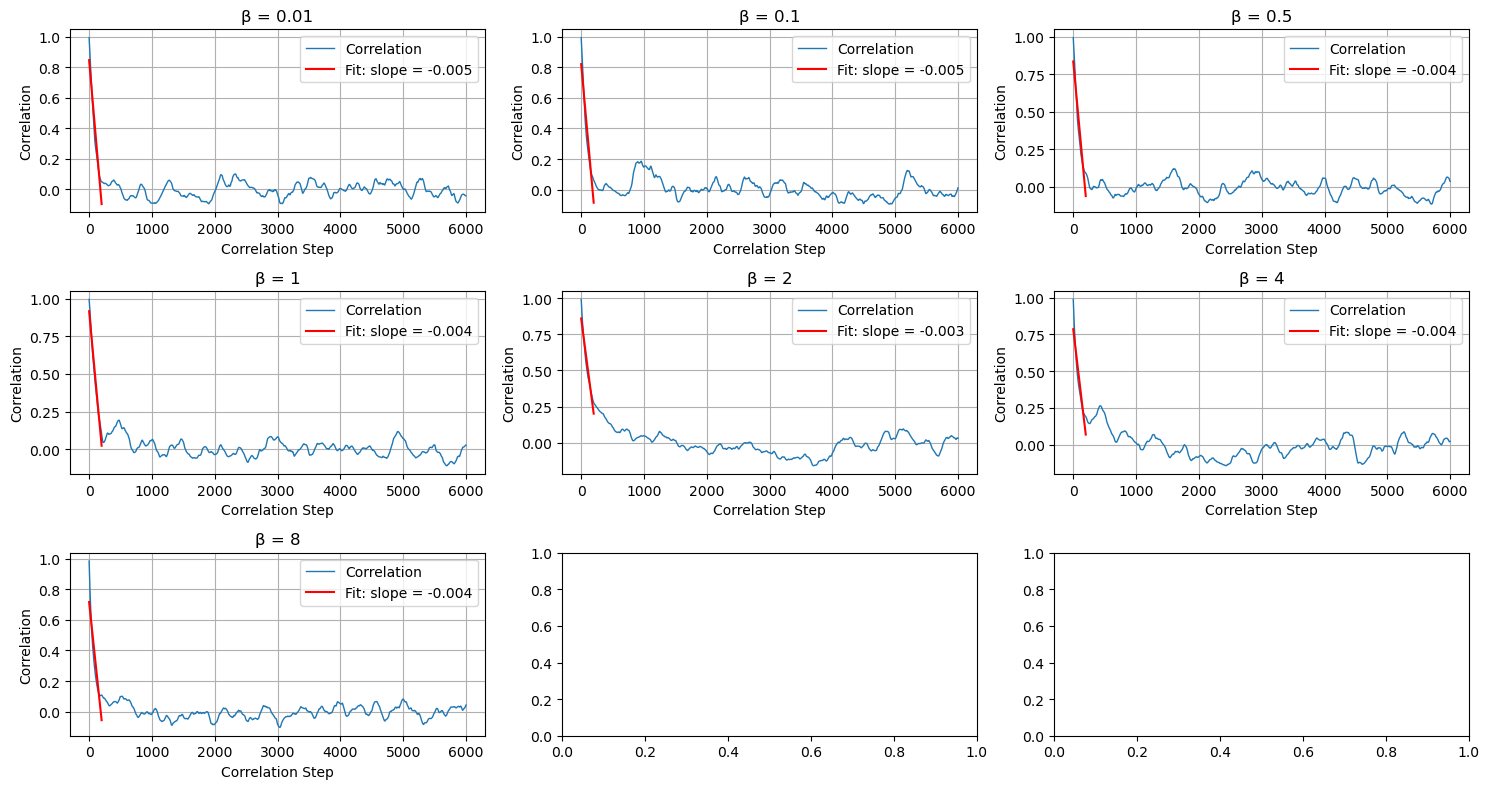

Slope for β = 0.01: -0.005
Slope for β = 0.1: -0.005
Slope for β = 0.5: -0.004
Slope for β = 1: -0.004
Slope for β = 2: -0.003
Slope for β = 4: -0.004
Slope for β = 8: -0.004


In [ ]:
from scipy.stats import linregress
slopes = []  # To store slopes for each beta

# Plot the correlations and calculate the slope
fig, axes = plt.subplots(3, 3, figsize=(15, 8))  # 2 rows x 3 columns
axes = axes.flatten()  # So we can index them easily with a single loop

for i, b in enumerate(betas):
    ax = axes[i]
    cor_values = correlations_array[i]
    
    # Select first 1000 values for the linear fit
    range = 200
    x_vals = np.arange(range)  # X values for linear fit (steps)
    y_vals = cor_values[:range]  # First 1000 correlation values
    
    # Perform linear fit: y = mx + c, extract the slope (m)
    slope, intercept, r_value, p_value, std_err = linregress(x_vals, y_vals)
    
    # Store the slope for this beta
    slopes.append(slope)
    
    # Plot the correlation curve and linear fit
    ax.plot(cor_values, marker='', linestyle='-', linewidth=1, label="Correlation")
    ax.plot(x_vals, slope * x_vals + intercept, color='r', label=f"Fit: slope = {slope:.3f}")
    ax.set_title(f"β = {b}")
    ax.set_xlabel("Correlation Step")
    ax.set_ylabel("Correlation")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
# plt.savefig(cwd + '/CODE/AttentionDCA_python/src/PLM/generated_sequences/beta_correlations_grid.pdf')
plt.show()

# Print the slopes for each beta
for i, b in enumerate(betas):
    print(f"Slope for β = {b}: {slopes[i]:.3f}")

In [ ]:

#----------- Load sequences with different betas -------------
cwd = '/Users/marzioformica/Desktop/EPFL/Master/MA2/Labo/my_project/PLM-gen-DCA/Attention-DCA-main'
#cwd='C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main'
save_dir = 'mc_generated_sequences'

betas = [0.01, 0.1, 0.5, 1, 2, 4, 8]
correlations_means = []
correlations_array = []  # Will become a 2D array: len(betas) x len(correlation steps)

for b in betas:
    filename = f'mc_gen_seqs_w_init_seq_Ns100000_r0.1_b{b}'
    output_file = cwd + f'/CODE/AttentionDCA_python/src/PLM/{save_dir}/{filename}.npy'
    gen_sequences = np.load(output_file)

    initial_sequence = gen_sequences[0]
    hamming_distances = []
    for seq in gen_sequences:
        distance = hamming_dist(initial_sequence, seq)
        hamming_distances.append(distance)
    hamming_distances = np.array(hamming_distances)
    result = energy_corr_array(hamming_distances, int(len(hamming_distances)/5))
    correlations_array.append(result)
    correlation = np.mean(result[-1000:])
    correlations_means.append(correlation)
correlations_means = np.array(correlations_means)
correlations_array = np.array(correlations_array)

print(np.shape(correlations_array))

(7, 20000)


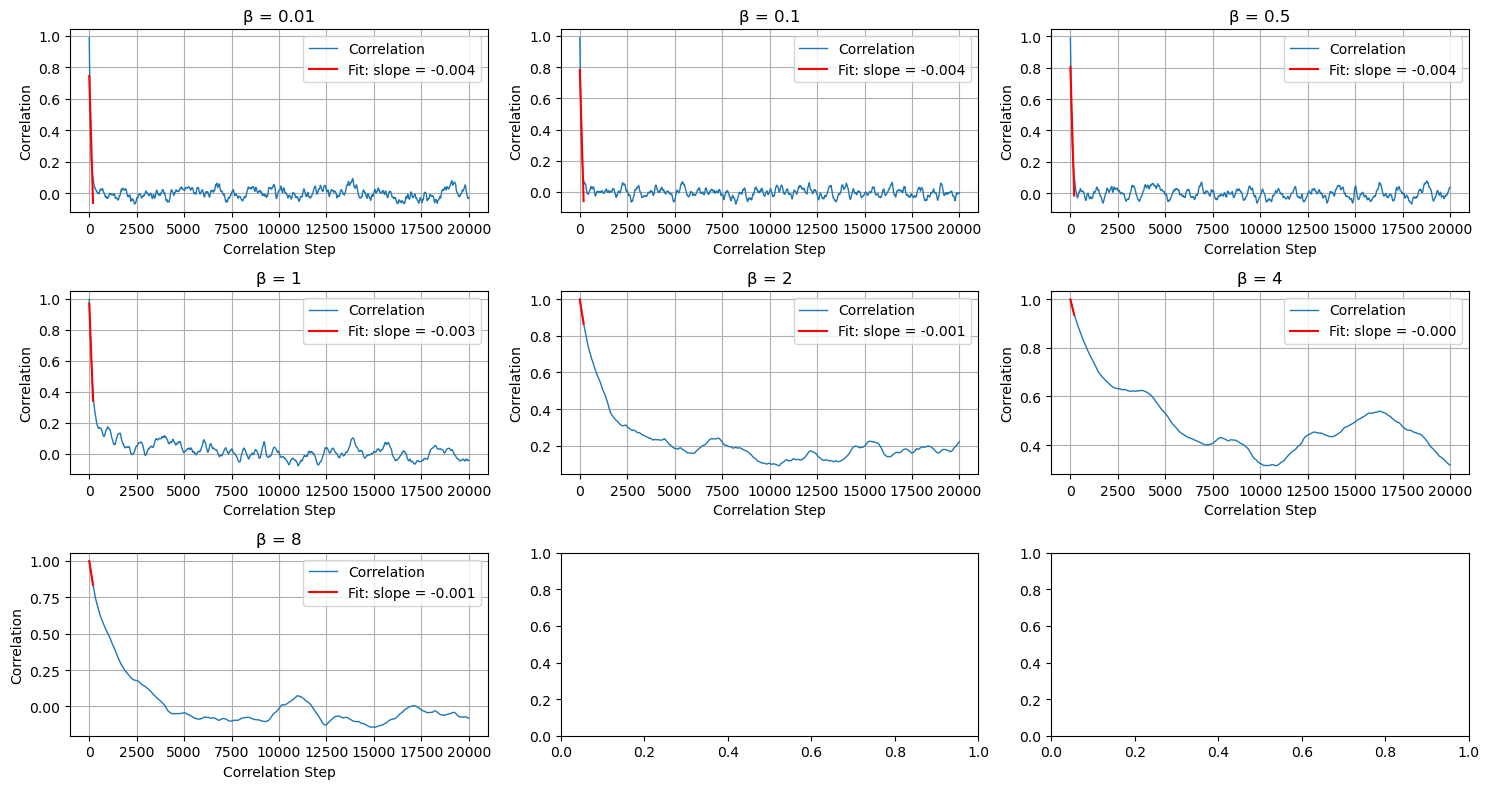

Slope for β = 0.01: -0.004
Slope for β = 0.1: -0.004
Slope for β = 0.5: -0.004
Slope for β = 1: -0.003
Slope for β = 2: -0.001
Slope for β = 4: -0.000
Slope for β = 8: -0.001


In [ ]:
from scipy.stats import linregress
slopes = []  # To store slopes for each beta

# Plot the correlations and calculate the slope
fig, axes = plt.subplots(3, 3, figsize=(15, 8))  # 2 rows x 3 columns
axes = axes.flatten()  # So we can index them easily with a single loop

for i, b in enumerate(betas):
    ax = axes[i]
    cor_values = correlations_array[i]
    
    # Select first 1000 values for the linear fit
    range = 200
    x_vals = np.arange(range)  # X values for linear fit (steps)
    y_vals = cor_values[:range]  # First 1000 correlation values
    
    # Perform linear fit: y = mx + c, extract the slope (m)
    slope, intercept, r_value, p_value, std_err = linregress(x_vals, y_vals)
    
    # Store the slope for this beta
    slopes.append(slope)
    
    # Plot the correlation curve and linear fit
    ax.plot(cor_values, marker='', linestyle='-', linewidth=1, label="Correlation")
    ax.plot(x_vals, slope * x_vals + intercept, color='r', label=f"Fit: slope = {slope:.3f}")
    ax.set_title(f"β = {b}")
    ax.set_xlabel("Correlation Step")
    ax.set_ylabel("Correlation")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
# plt.savefig(cwd + '/CODE/AttentionDCA_python/src/PLM/generated_sequences/beta_correlations_grid.pdf')
plt.show()

# Print the slopes for each beta
for i, b in enumerate(betas):
    print(f"Slope for β = {b}: {slopes[i]:.3f}")